# Prompt Engineering for Vision Models


Аудіо, відео, текст та зображення можна перетворити в векторні дані (embedding), та передати в модель.

Input vs Prompt: 
- Input: зображення та prompt "підкресли об'єкт справа на зображенні"

Fine-tuning -> model training -> model evaluation -> model architecture -> fine tuning

## Сегментація зображень (image segmentation)

!pip install ultralytics torch


Image segmantation - locate boundaries of imagies, assign labels to every part of image.

Image encoder + prompt encoder -> mask decoder

FastSAM - fast segment anything

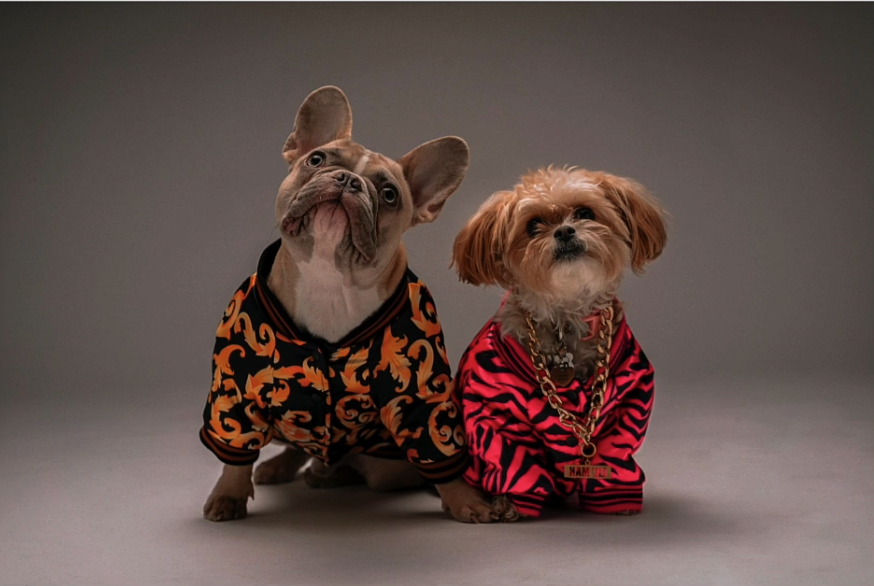

In [1]:
from PIL import Image
raw_image = Image.open("./images/dogs.jpg")
raw_image

Resize the image:

In [ ]:
from utils import resize_image
resized_image = resize_image(raw_image, input_size=1024)
resized_image

Import and prepare the model:

In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [4]:
from ultralytics import YOLO
model = YOLO('../saved_models/FastSAM-s.pt')

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\first\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# Run the model
results = model(raw_image, device=device, retina_masks=True)


0: 448x640 18 objects, 532.9ms
Speed: 57.5ms preprocess, 532.9ms inference, 210.3ms postprocess per image at shape (1, 3, 448, 640)


Generate masks on images 



## Object detection:

In [6]:
from transformers import pipeline

pipe = pipeline(
    task="zero-shot-object-detection", 
    model="google/owlvit-base-patch32")


# What you want to identify in the image
text_prompt = "dog"

output = pipe(
    raw_image,
    candidate_labels = [text_prompt]
)
print(output)

C:\Users\first\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\first\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\first\.cache\huggingface\hub\models--google--owlvit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggi

[{'score': 0.20375965535640717, 'label': 'dog', 'box': {'xmin': 195, 'ymin': 86, 'xmax': 485, 'ymax': 521}}, {'score': 0.20191793143749237, 'label': 'dog', 'box': {'xmin': 438, 'ymin': 165, 'xmax': 681, 'ymax': 528}}]


**Model Distillation** - process of transferring knowledge from a lrage model to a smaller one

**Get segmentation masks using Mobile SAM**

In [ ]:
from ultralytics import SAM
import numpy as np

SAM_version = "mobile_sam.pt"
model = SAM(SAM_version)

# Create a list of positive labels of same length as the number of predictions generated above
labels = np.repeat(1, len(output))

# Print the labels
print(labels)

result = model.predict(
    raw_image,
    bboxes=input_boxes[0],
    labels=labels
)

